## 🔧 Training Hyperparameters (for reproducibility)

**Model:** ResNet18 (grayscale adaptation)

**Optimizer:** SGD (Stochastic Gradient Descent)
- Learning rate: 0.1
- Momentum: 0.9
- Weight decay: 5e-4

**Batch size:** 64

**Epochs:** 5

**Scheduler:** StepLR (step_size=30, gamma=0.1)

**Loss function:** CrossEntropyLoss (with class weights)

**Data augmentation:**
- RandomHorizontalFlip
- RandomCrop (64x64, padding=4)

**Device:** CUDA (if available), else CPU

_Update these values if you change any hyperparameters during experimentation._

In [1]:
# key imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision import datasets
import torchvision
import torchvision.transforms as transforms
from torchvision.io import read_image 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import cv2
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Set random seed for reproducibility
import random
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Load Data and Preprocessing Metadata

In [3]:
# dataset path
dataset_path = '../data/processed'
splits = ['Training', 'Testing', 'Validation']

In [4]:
import json
metadata_path = os.path.join(dataset_path, 'preprocessing_metadata.json')
if not os.path.exists(metadata_path):
    raise FileNotFoundError(f"Metadata file not found: {metadata_path}")

try:
    with open(metadata_path, 'r') as f:
        preprocessing_metadata = json.load(f)
except json.JSONDecodeError as e:
    raise ValueError(f"Error decoding JSON from {metadata_path}: {e}")

In [5]:
required_keys = ['class_mapping', 'training_class_weights', 'testing_class_weights', 'validation_class_weights']
for key in required_keys:
    if key not in preprocessing_metadata:
        raise KeyError(f"Missing key '{key}' in preprocessing metadata.")

In [6]:
# save class names for later use
class_mapping = preprocessing_metadata['class_mapping']
print(f"Class mapping: {class_mapping}")
classes = [class_mapping[str(i)] for i in range(len(class_mapping))]
class_indices = [str(i) for i in range(len(class_mapping))]

# verify indices match expected classes
assert class_mapping['0'] == classes[0]  # glioma_tumor
assert class_mapping['1'] == classes[1]  # meningioma_tumor
assert class_mapping['2'] == classes[2]  # no_tumor
assert class_mapping['3'] == classes[3]  # pituitary_tumor

Class mapping: {'0': 'glioma_tumor', '1': 'meningioma_tumor', '2': 'no_tumor', '3': 'pituitary_tumor'}


In [7]:
# read in class weights 
training_weights = preprocessing_metadata['training_class_weights']
print(f"Training class weights: {training_weights}")

testing_weights = preprocessing_metadata['testing_class_weights']
print(f"Testing class weights: {testing_weights}")

validation_weights = preprocessing_metadata['validation_class_weights']
print(f"Validation class weights: {validation_weights}")

Training class weights: {'0': 0.7921216848673946, '1': 0.8970848056537103, '2': 2.71524064171123, '3': 0.7970957613814756}
Testing class weights: {'0': 0.7847593582887701, '1': 1.0262237762237763, '2': 1.3587962962962963, '3': 0.9848993288590604}
Validation class weights: {'0': 0.8521739130434782, '1': 0.9751243781094527, '2': 4.0, '3': 0.6447368421052632}


In [8]:
# read in pixel mean and std for normalization
train_mean = preprocessing_metadata['normalization']['mean']
train_std = preprocessing_metadata['normalization']['std']

## CSV File

We need a csv file that contains one line for each image: 'path, label'. 

In [9]:
for split in splits:
    image_list = []
    # open a new csv file for each split
    with open(f'../data/processed/mri_dataset_{split}.csv', 'w') as f:
        for cls in classes:
            class_dir = os.path.join(dataset_path, split, cls)
            for img_name in os.listdir(class_dir):
                full_path = os.path.join(class_dir, img_name)
                tuple = (full_path, cls)
                image_list.append(tuple)

        # save to csv
        f.write('image_path,label\n')
        for item in image_list:
            f.write(f'{item[0]},{item[1]}\n')

In [10]:
class custom_dataset(Dataset):
    # defining constructor
    def __init__(self, annotations, directory, transform=None):
        # directory containing the images
        self.directory = directory
        
        annotations_file_dir = os.path.join(self.directory, annotations)

        if not os.path.exists(annotations_file_dir):
            raise FileNotFoundError(f"Dataset CSV not found: {annotations_file_dir}")

        try:
            self.labels = pd.read_csv(annotations_file_dir)
        except Exception as e:
            raise ValueError(f"Error reading CSV file {annotations_file_dir}: {e}")

        if 'image_path' not in self.labels.columns or 'label' not in self.labels.columns:
            raise ValueError(f"CSV file {annotations_file_dir} missing required columns 'image_path' and 'label'.")



        # transform to be applied on images
        self.transform = transform
 
        # Number of images in dataset
        self.len = self.labels.shape[0]
 
    # getting the length
    def __len__(self):
        return len(self.labels)
 
    # getting the data items
    def __getitem__(self, idx):
        # defining the image path
        image_path = self.labels.iloc[idx, 0]
        # reading the images
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) # reads image into a numpy array of shape (H, W) since it's grayscale
        # corresponding class labels of the images 
        label = self.labels.iloc[idx, 1]
 
        # apply the transform if not set to None
        if self.transform:
            image = Image.fromarray(image) # convert numpy array to PIL Image
            image = self.transform(image) # apply the transform to the image, which will convert it to a tensor and normalize it
        
        # returning the image and label
        return image, label

In [11]:
# print type of the custom dataset images
print(type(custom_dataset))

<class 'type'>


## Dataset and Transformations Explanation

The next cell creates the training, testing, and validation datasets for the MRI brain tumor project, using a custom PyTorch Dataset class. Each dataset is wrapped in a DataLoader for batching and shuffling.

### Transformations

- **Training Transform (`transform_train`)**:  
  - `RandomHorizontalFlip()`: Randomly flips images horizontally with a default probability of 0.5.
  - `ToTensor()`: Converts PIL images or numpy arrays to PyTorch tensors.
  - `Normalize((0.5,), (0.5,))`: Normalizes the tensor so that pixel values are scaled to have mean 0.5 and standard deviation 0.5 (for grayscale images).

- **Test/Validation Transform (`transform_test`)**:  
  - Only `ToTensor()` and `Normalize((0.5,), (0.5,))` are applied. No augmentation, so images are just converted and normalized.

### Normalization Constants

- The constants `(0.5,)` for mean and std are used to scale pixel values.  
  - After `ToTensor()`, pixel values are in `[0, 1]`.
  - Normalization transforms them to `(value - 0.5) / 0.5`, so values are centered around 0.

### Augmentation

- **RandomHorizontalFlip**: About half of the training images are flipped.
- **RandomCrop**: All training images are cropped (with random position and padding).
- **Test/Validation**: No augmentation, only conversion and normalization.

---

**Summary:**  
- Training set: Augmented (flip/crop), converted, normalized.
- Test/validation: Only converted and normalized.
- Normalization centers pixel values around 0.

In [12]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize((train_mean,), (train_std,))
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((train_mean,), (train_std,))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((train_mean,), (train_std,))
])

# training dataset
trainset = custom_dataset(annotations='mri_dataset_Training.csv', directory='../data/processed', transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=0)

testset = custom_dataset(annotations='mri_dataset_Testing.csv', directory='../data/processed', transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=0)

valset = custom_dataset(annotations='mri_dataset_Validation.csv', directory='../data/processed', transform=transform_test)
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=False, num_workers=0)

In [13]:
# display number of images in each split
print(f'Number of training images: {len(trainset)}')
print(f'Number of testing images: {len(testset)}')
print(f'Number of validation images: {len(valset)}')

# display the path and label of the first image in trainset
print(f'Path of the first image in trainset: {trainset.labels.iloc[0, 0]}')
print(f'Label of the first image in trainset: {trainset.labels.iloc[0, 1]}')

Number of training images: 2031
Number of testing images: 587
Number of validation images: 784
Path of the first image in trainset: ../data/processed/Training/glioma_tumor/gg (362).jpg
Label of the first image in trainset: glioma_tumor


# Load Model

In [14]:
import torchvision.models as models

# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modify first conv layer for grayscale input
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
# Initialize the new conv layer's weights using Kaiming initialization
nn.init.kaiming_normal_(model.conv1.weight, mode='fan_out', nonlinearity='relu')

# Modify final layer for your number of classes
model.fc = nn.Linear(512, len(classes))

# print(model)

In [15]:
# Example: if training_weights is a list or numpy array
# convert training weights to list of floats
training_weights = list(training_weights.values())
# convert to tensor and move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = torch.tensor(training_weights, dtype=torch.float32).to(device)

In [16]:
print(type(class_weights))
print(class_weights)

<class 'torch.Tensor'>
tensor([0.7921, 0.8971, 2.7152, 0.7971])


In [17]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

# Initial Performance

Out of curiosity, I want to see how accurate the model is before I do any training. The default ResNet18 weights give it an accuracy of roughly 25% when classifying mri tumor images.

In [18]:
# evaluate the models performance on the validation set before training
model.eval()
correct = 0
total = 0

with torch.no_grad(): # disable gradient calculation for evaluation
    # iterate through the validation data
    for images, labels in valloader:
        # forward pass through the model to get predictions
        outputs = model(images)
        # get the predicted class by finding the index of the maximum output value
        _, predicted = torch.max(outputs.data, 1)
        total += len(images)
        for i in range(len(labels)):
            label_index = classes.index(labels[i])
            correct += (predicted[i] == label_index)

print(f'Validation Accuracy before training: {100 * correct / total:.2f}%')

Validation Accuracy before training: 25.64%


# Model Training

This section trains the model iteratively over a series of epochs. Training automatically leverages a GPU if available, falling back to CPU otherwise.
The training loop is designed to be modular and resumable — if you wish to continue training beyond the initial run, simply re-execute the epoch loop. Training and validation metrics (loss and accuracy) are recorded each epoch and appended to existing NumPy arrays, allowing learning curves to reflect the full training history across multiple runs.

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [27]:
# utility functions to save and load training curves
def save_curves(filename, data):
    # saves data to filename
    np.save(filename, np.array(data, dtype=np.float32))

def load_curves(filename):
    # loads data from filename if it exists, otherwise returns an empty list
    if os.path.exists(filename):
        return list(np.load(filename).tolist())
    else:
        return []

In [28]:
# remove existing curves if they exist
if os.path.exists('train_losses.npy'):
    os.remove('train_losses.npy')
if os.path.exists('train_accs.npy'):    
    os.remove('train_accs.npy')
if os.path.exists('val_losses.npy'):
    os.remove('val_losses.npy')
if os.path.exists('val_accs.npy'):
    os.remove('val_accs.npy')

In [29]:
# load or initialize training curves
train_losses = load_curves("train_losses.npy")
val_losses = load_curves("val_losses.npy")
train_accs = load_curves("train_accs.npy")
val_accs = load_curves("val_accs.npy")

In [30]:
# verify that curves are empty
print(f"Initial train losses: {train_losses}")
print(f"Initial validation losses: {val_losses}")
print(f"Initial train accuracies: {train_accs}")
print(f"Initial validation accuracies: {val_accs}")

Initial train losses: []
Initial validation losses: []
Initial train accuracies: []
Initial validation accuracies: []


In [31]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001, mode='min'):
        """
        patience: epochs to wait without improvement before stopping
        min_delta: minimum change to count as improvement
        mode: 'max' for accuracy, 'min' for loss
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = float('-inf') if mode == 'max' else float('inf')
        self.counter = 0
        self.best_weights = None

    def step(self, metric, model):
        improved = (
            metric > self.best + self.min_delta if self.mode == 'max'
            else metric < self.best - self.min_delta
        )
        if improved:
            self.best = metric
            self.counter = 0
            self.best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1

        return self.counter >= self.patience  # returns True → stop

    def restore_best(self, model):
        if self.best_weights:
            model.load_state_dict(self.best_weights)
            print(f"Restored best weights (best val metric: {self.best:.4f})")

In [32]:
num_epochs = 20
early_stopping = EarlyStopping(5, 0.001, 'min')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        # Convert labels to integer indices if needed
        if isinstance(labels[0], str):
            labels = [classes.index(lbl) for lbl in labels]
        labels = torch.tensor(labels, dtype=torch.long, device=device)
        optimizer.zero_grad() # zero the parameter gradients
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0) # accumulate loss over the epoch
        # get predicted class
        _, predicted = outputs.max(1)
        # calculate accuracy
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_loss = running_loss / len(trainloader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Evaluate on val set
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in valloader:
            # convert labels to integer indices if needed
            inputs = inputs.to(device)
            if isinstance(labels[0], str):
                labels = [classes.index(lbl) for lbl in labels]
            labels = torch.tensor(labels, dtype=torch.long, device=device)
            outputs = model(inputs)
            # check output shape and label shape
            assert outputs.shape[0] == labels.shape[0], f"Batch size mismatch: outputs batch size {outputs.shape[0]} vs labels batch size {labels.shape[0]}"
            loss = criterion(outputs, labels)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            running_loss += loss.item() * inputs.size(0) # accumulate loss over the epoch

    val_loss = running_loss / len(valloader.dataset)
    val_acc = 100. * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # check for overfitting
    if early_stopping.step(val_loss, model):
        print(f"Early stopping at epoch {epoch+1}")
        break

    # restore best model
    early_stopping.restore_best(model)

    # save progress after each epoch
    save_curves("train_losses.npy", train_losses)
    save_curves("val_losses.npy", val_losses)
    save_curves("train_accs.npy", train_accs)
    save_curves("val_accs.npy", val_accs)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} || Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Restored best weights (best val metric: 0.8111)
Epoch [1/20] Train Loss: 0.5524 || Train Acc: 78.04% | Val Loss: 0.8111 | Val Acc: 73.98%
Restored best weights (best val metric: 0.8111)
Epoch [2/20] Train Loss: 0.2442 || Train Acc: 90.60% | Val Loss: 1.1333 | Val Acc: 71.17%
Restored best weights (best val metric: 0.2800)
Epoch [3/20] Train Loss: 0.1969 || Train Acc: 92.22% | Val Loss: 0.2800 | Val Acc: 89.41%
Restored best weights (best val metric: 0.2800)
Epoch [4/20] Train Loss: 0.2550 || Train Acc: 90.79% | Val Loss: 0.7283 | Val Acc: 81.12%
Restored best weights (best val metric: 0.1751)
Epoch [5/20] Train Loss: 0.1341 || Train Acc: 94.98% | Val Loss: 0.1751 | Val Acc: 94.26%
Restored best weights (best val metric: 0.1751)
Epoch [6/20] Train Loss: 0.0908 || Train Acc: 96.31% | Val Loss: 0.2216 | Val Acc: 93.11%
Restored best weights (best val metric: 0.1751)
Epoch [7/20] Train Loss: 0.0657 || Train Acc: 97.39% | Val Loss: 0.2577 | Val Acc: 90.94%
Restored best weights (best val me

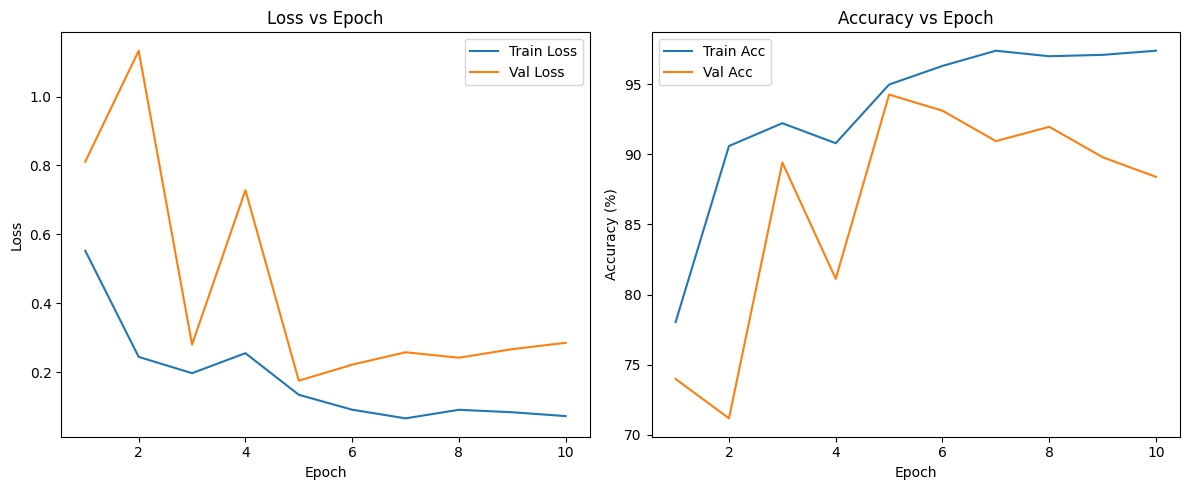

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot training loss and accuracy
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
n = len(train_losses)+1

plt.plot(range(1, n), train_losses, label='Train Loss')
plt.plot(range(1, n), val_losses, label='Val Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.plot(range(1, n), train_accs, label='Train Acc')
plt.plot(range(1, n), val_accs, label='Val Acc')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch') 
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

# save to assets
plt.savefig('../assets/training_curves.png')

# Model Evaluation

### Confusion Matrix

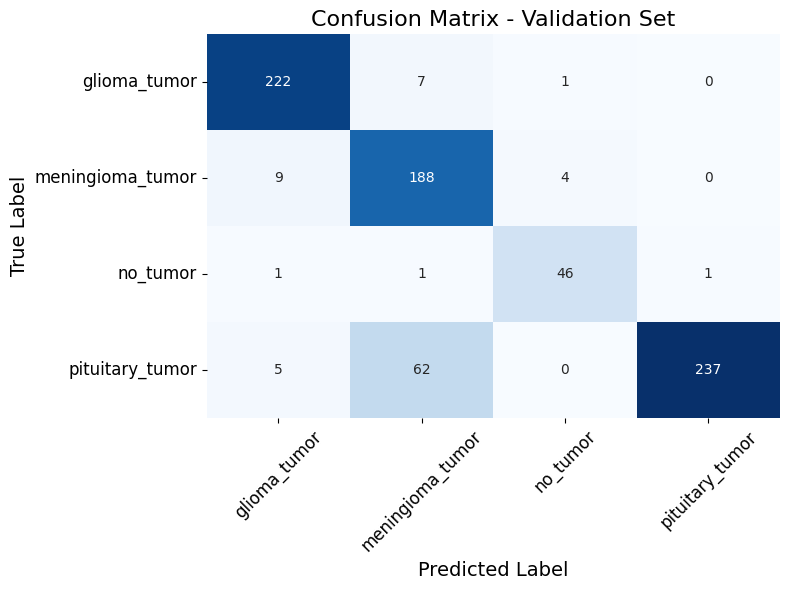

In [35]:
# create confusion matrix for validation set
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for inputs, labels in valloader:
        inputs = inputs.to(device)
        if isinstance(labels[0], str):
            labels = [classes.index(lbl) for lbl in labels]
        labels = torch.tensor(labels, dtype=torch.long, device=device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=False)
plt.title('Confusion Matrix - Validation Set', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('../assets/confusion_matrix.png')
plt.show()

### False Positives, Negatives, Precision, Recall

In [36]:
# false negatives are really bad 
# count instances where true label is tumor but predicted is no_tumor
false_negatives = 0
for true, pred in zip(all_labels, all_preds):
    # check if true label is tumor (1, 2, or 3) but predicted is no_tumor (0)
    if true in [1, 2, 3] and pred == 0:
        false_negatives += 1
print(f'Number of false negatives (tumor predicted as no_tumor): {false_negatives}')
print(f'Rate of false negatives: {false_negatives / len(all_labels) * 100:.2f}%')

Number of false negatives (tumor predicted as no_tumor): 15
Rate of false negatives: 1.91%


In [37]:
# count instances where true label is no_tumor (0) but predicted is tumor (1, 2, or 3)
false_positives = 0
for true, pred in zip(all_labels, all_preds):
    # check if true label is no_tumor (0) but predicted is tumor (1, 2, or 3)
    if true == 0 and pred in [1, 2, 3]:
        false_positives += 1
print(f'Number of false positives (no_tumor predicted as tumor): {false_positives}')
print(f'Rate of false positives: {false_positives / len(all_labels) * 100:.2f}%')

Number of false positives (no_tumor predicted as tumor): 8
Rate of false positives: 1.02%


In [38]:
# precision, recall, and F1 score
from sklearn.metrics import precision_score, recall_score, f1_score

# precision score
precision = precision_score(all_labels, all_preds, average='weighted')
print(f'Precision: {precision:.4f}')

# recall score
recall = recall_score(all_labels, all_preds, average='weighted')
print(f'Recall: {recall:.4f}')

# F1 score
f1 = f1_score(all_labels, all_preds, average='weighted')
print(f'F1 Score: {f1:.4f}')

Precision: 0.9041
Recall: 0.8839
F1 Score: 0.8855


# Save the Model

We'll save the model for later use, such as deployment. To do this, it's only necessary to save the model weights.

In [39]:
# create models directory if it doesn't already exist
if not os.path.exists('../models'):
    os.makedirs('../models')

# Save model weights
torch.save(model.state_dict(), "../models/resnet18_brain_tumor_weights.pth")

In [40]:
# To reload:
model = models.resnet18(weights=None)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.fc = nn.Linear(512, len(classes))
model.load_state_dict(torch.load("../models/resnet18_brain_tumor_weights.pth"))
model = model.to(device)
model.eval()

/var/folders/bz/l_61zlvj34gcp1c8znmr81rr0000gn/T/ipykernel_63434/3186448929.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../models/r

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Summary